# Byte-pair Encoding

A brief introduction to BPE and path for experimentation.

In [1]:
# %pip install -q "huggingface_hub>=0.34"
from pathlib import Path
from huggingface_hub import hf_hub_download

REPO = "roneneldan/TinyStories"
DATA = Path("data")
FILES = ["TinyStoriesV2-GPT4-valid.txt", "TinyStoriesV2-GPT4-train.txt"]

paths = {
    name: Path(hf_hub_download(
        repo_id=REPO, repo_type="dataset", filename=name, local_dir=DATA,
    ))
    for name in FILES
}

for name, p in paths.items():
    print(f"{name:35s} {p.stat().st_size / 1e6:8.1f} MB  ->  {p}")

TinyStoriesV2-GPT4-valid.txt:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

TinyStoriesV2-GPT4-train.txt:   0%|          | 0.00/2.23G [00:00<?, ?B/s]

TinyStoriesV2-GPT4-valid.txt            22.5 MB  ->  data/TinyStoriesV2-GPT4-valid.txt
TinyStoriesV2-GPT4-train.txt          2227.8 MB  ->  data/TinyStoriesV2-GPT4-train.txt


In [11]:
# Cell 1b — corpus registry (config; independent of the download results in `paths`)
CORPORA = {
    "valid":  DATA / "TinyStoriesV2-GPT4-valid.txt",   # ~22 MB, present after cell 1
    "train":  DATA / "TinyStoriesV2-GPT4-train.txt",   # ~2.2 GB, present after cell 1
    "sample": DATA / "TinyStoriesV2-GPT4-sample.txt",  # created by cell 3
}

def corpus(name: str) -> Path:
    p = CORPORA[name]
    if not p.exists():
        hint = "Run cell 3 to build it." if name == "sample" else "Run cell 1 to download it."
        raise FileNotFoundError(f"{name!r} -> {p} not found. {hint}")
    return p

CORPUS = "sample"   # the single knob — set to "sample" once cell 3 has run

In [16]:
import numpy as np
from collections import Counter

DEV = corpus(CORPUS)
SEP = "<|endoftext|>"

# read_text with strict UTF-8 — if it raised, that malformed-bytes finding would matter
text = DEV.read_text(encoding="utf-8")
pieces = text.split(SEP)
docs = [d.strip() for d in pieces]
nonempty = [d for d in docs if d]

# --- structure ---
print(f"file                : {DEV.name}")
print(f"raw size            : {len(text.encode('utf-8'))/1e6:.1f} MB")
print(f"separators found    : {text.count(SEP):,}")
print(f"pieces after split  : {len(pieces):,}")
print(f"non-empty documents : {len(nonempty):,}")
print(f"empty / whitespace  : {len(docs) - len(nonempty):,}")

# first & last pieces: noanabeshima's pipeline drops these as broken — verify, don't assume
print(f"\nfirst piece ({len(pieces[0]):>4} chars): {pieces[0][:100]!r}")
print(f"last  piece ({len(pieces[-1]):>4} chars): {pieces[-1][:100]!r}")

print(f"\n--- sample document ---\n{nonempty[1][:600]}\n")

# --- length distribution, in UTF-8 bytes ---
blen = np.array([len(d.encode('utf-8')) for d in nonempty])
labels = ["min", "median", "p90", "p95", "p99", "max"]
vals = np.percentile(blen, [0, 50, 90, 95, 99, 100]).astype(int)
print("document length (UTF-8 bytes)")
for lab, v in zip(labels, vals):
    print(f"  {lab:6s}: {v:>7,}")
print(f"  mean  : {blen.mean():>7.0f}")

# --- non-ASCII inventory: the 'should I clean?' evidence ---
joined = "\n".join(nonempty)
na = Counter(c for c in joined if ord(c) > 127)
share = sum(na.values()) / len(joined)
print(f"\nnon-ASCII: {sum(na.values()):,} of {len(joined):,} chars ({share:.3%})")
for c, n in na.most_common(12):
    print(f"  U+{ord(c):04X}  {c!r:8s}  {n:,}")

file                : TinyStoriesV2-GPT4-sample.txt
raw size            : 210.0 MB
separators found    : 255,977
pieces after split  : 255,978
non-empty documents : 255,977
empty / whitespace  : 1

first piece ( 516 chars): 'Once upon a time, there was a little rabbit named Remy. Remy lived near a hedge. One day, Remy felt '
last  piece (   1 chars): '\n'

--- sample document ---
Anna and Ben like to play outside. They have a big yard with a swing, a slide and a sandbox. They also have sunglasses to protect their eyes from the sun. Anna has pink sunglasses and Ben has blue sunglasses.
One day, they decide to play pirates. They put on their sunglasses and pretend they are looking for treasure. Anna has a map and Ben has a shovel. They dig in the sandbox and find some shiny stones and shells. They are very happy and put them in a bucket.
But then, Ben is clumsy and trips over the bucket. He falls and spills the treasure all over the ground. He also breaks his sunglasses.

document length

In [19]:
import random

SRC    = corpus("train")
SAMPLE = CORPORA["sample"]
TARGET = 200 * 1024 * 1024          # ~200 MB of text
SEED   = 0

def iter_documents(path, sep=SEP):
    """Stream complete documents from a separator-delimited corpus.
    Peak memory is a single document, not the file."""
    buf = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.startswith(sep):
                if buf:
                    yield "".join(buf).strip()
                    buf = []
            else:
                buf.append(line)          # trailing '\n' kept: internal structure preserved
    if buf:
        yield "".join(buf).strip()

# Bernoulli sampling: keep each document independently with probability p.
rng = random.Random(SEED)
p = TARGET / SRC.stat().st_size          # slight under-estimate; separators inflate file size
kept = kept_bytes = seen = 0

with open(SAMPLE, "w", encoding="utf-8") as out:
    for doc in iter_documents(SRC):
        seen += 1
        if doc and rng.random() < p:
            out.write(doc + f"\n{SEP}\n")   # re-emit separator: same format as source
            kept += 1
            kept_bytes += len(doc.encode("utf-8"))

print(f"scanned : {seen:,} documents")
print(f"kept    : {kept:,} ({kept/seen:.2%})")
print(f"size    : {kept_bytes/1e6:.1f} MB  ->  {SAMPLE}")

scanned : 2,717,700 documents
kept    : 255,977 (9.42%)
size    : 206.1 MB  ->  data/TinyStoriesV2-GPT4-sample.txt


In [20]:
# %pip install -q regex        # NB: third-party `regex`, not stdlib `re` — needed for \p{L} etc.
import regex as re
from collections import Counter

# GPT-2's pretokenisation pattern (the one tiktoken uses for r50k/gpt2).
# Splits off contractions, keeps a leading space attached to its word,
# and groups letters / numbers / punctuation / whitespace runs separately.
GPT2_PAT = re.compile(
    r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
)

def pretokenise(path):
    """Stream documents -> {pretoken_as_byte_tuple: count}.

    Counts on strings first (cheap: the corpus is hugely repetitive),
    then encodes each *unique* pretoken to UTF-8 once, as a tuple of
    single bytes -- the representation the merge loop consumes.
    """
    str_freqs = Counter()
    for doc in iter_documents(path):          # cell 3: SEP-free, stripped documents
        str_freqs.update(GPT2_PAT.findall(doc))
    return {
        tuple(bytes([b]) for b in s.encode("utf-8")): c
        for s, c in str_freqs.items()
    }

word_freqs = pretokenise(corpus(CORPUS))

# --- sanity check ---
n_unique = len(word_freqs)
n_tokens = sum(word_freqs.values())
n_bytes  = sum(len(t) * c for t, c in word_freqs.items())
print(f"corpus          : {CORPUS}")
print(f"unique pretokens: {n_unique:,}")
print(f"total pretokens : {n_tokens:,}")
print(f"total bytes     : {n_bytes:,}   (initial length, before any merge)")

print("\nmost frequent pretokens:")
for t, c in sorted(word_freqs.items(), key=lambda kv: kv[1], reverse=True)[:20]:
    s = b"".join(t).decode("utf-8", errors="replace")
    print(f"  {c:>9,}  {s!r}")

corpus          : sample
unique pretokens: 27,251
total pretokens : 50,010,583
total bytes     : 206,112,578   (initial length, before any merge)

most frequent pretokens:
  3,942,224  '.'
  2,192,499  ','
  1,965,074  ' the'
  1,837,178  ' and'
  1,418,698  ' a'
  1,403,474  ' to'
    999,098  ' was'
    858,682  '\n'
    494,288  ' They'
    483,767  ' it'
    456,318  ' He'
    450,922  ' "'
    435,722  ' The'
    412,652  ' said'
    397,796  ' with'
    397,113  ' day'
    365,698  ' She'
    363,222  ' her'
    362,707  ' in'
    355,418  ' his'


In [21]:
import time
from collections import Counter

def count_pairs(freqs):
    """All adjacent byte-pairs across the corpus, weighted by pretoken frequency.
    Only ever looks *inside* a tuple — the pretoken fence from cell 4."""
    pairs = Counter()
    for word, f in freqs.items():
        for a, b in zip(word, word[1:]):
            pairs[(a, b)] += f
    return pairs

def merge_pair(word, pair, new):
    """Rewrite one pretoken, gluing every non-overlapping occurrence of `pair`."""
    out, i, n = [], 0, len(word)
    while i < n:
        if i < n - 1 and word[i] == pair[0] and word[i + 1] == pair[1]:
            out.append(new); i += 2
        else:
            out.append(word[i]); i += 1
    return tuple(out)

def train_bpe(pretoken_freqs, vocab_size, special_tokens=("<|endoftext|>",),
              log_every=250):
    # base vocab: the 256 bytes (ids 0–255), then specials, then merges append after
    vocab = {i: bytes([i]) for i in range(256)}
    for tok in special_tokens:
        vocab[len(vocab)] = tok.encode("utf-8")
    n_merges = vocab_size - len(vocab)
    if n_merges < 0:
        raise ValueError(f"vocab_size {vocab_size} < base {len(vocab)}")

    freqs   = dict(pretoken_freqs)          # copy: never mutate cell 4's table
    merges  = []
    history = []
    total0  = sum(len(w) * f for w, f in freqs.items())   # initial length = total bytes
    total   = total0
    t0      = time.time()

    print(f"{'merge':>6} {'vocab':>6} {'piece':<22} {'count':>10} "
          f"{'tokens':>13} {'ratio':>6} {'sec':>7}")
    for step in range(n_merges):
        pairs = count_pairs(freqs)
        if not pairs:
            print(f"[stopped: no pairs left after {step} merges]")
            break

        best  = max(pairs, key=lambda p: (pairs[p], p))   # (1) most frequent, (2) lexicographically greatest
        count = pairs[best]
        new   = best[0] + best[1]

        vocab[len(vocab)] = new
        merges.append(best)
        freqs = {merge_pair(w, best, new): f for w, f in freqs.items()}

        total = sum(len(w) * f for w, f in freqs.items())
        history.append((step, best, count, total))

        if step % log_every == 0 or step == n_merges - 1:
            piece = new.decode("utf-8", errors="replace")
            print(f"{step:6d} {len(vocab):6d} {piece!r:<22} {count:>10,} "
                  f"{total:>13,} {total0/total:6.2f} {time.time()-t0:7.1f}")

    return vocab, merges, history

In [26]:
vocab, merges, history = train_bpe(word_freqs, vocab_size=10000, log_every=25)

 merge  vocab piece                       count        tokens  ratio     sec
     0    258 ' t'                    5,981,854   200,130,724   1.03     0.1
    25    283 'er'                    1,022,860   149,824,414   1.38     1.2
    50    308 'et'                      524,098   130,637,428   1.58     2.3
    75    333 ' o'                      397,025   119,603,758   1.72     3.4
   100    358 'all'                     285,252   111,079,473   1.86     4.5
   125    383 ' saw'                    231,837   104,610,404   1.97     5.5
   150    408 ' wanted'                 184,612    99,400,923   2.07     6.5
   175    433 'ue'                      160,210    95,096,885   2.17     7.6
   200    458 ' together'               132,636    91,462,266   2.25     8.6
   225    483 'my'                      111,635    88,489,659   2.33     9.6
   250    508 ' Sue'                     95,538    85,882,624   2.40    10.7
   275    533 ' felt'                    82,460    83,687,564   2.46    11.7

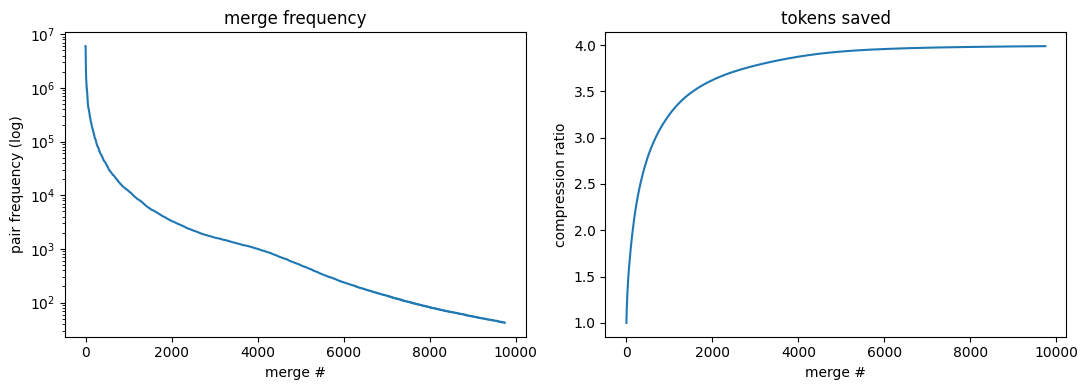

In [27]:
import matplotlib.pyplot as plt

steps  = [h[0] for h in history]
counts = [h[2] for h in history]
ratios = [h[3] and history[0][3] / h[3] for h in history]  # total0/total per step

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(steps, counts); ax1.set_yscale("log")
ax1.set(xlabel="merge #", ylabel="pair frequency (log)", title="merge frequency")
ax2.plot(steps, ratios)
ax2.set(xlabel="merge #", ylabel="compression ratio", title="tokens saved")
fig.tight_layout()